# Ejemplo de Aprendizaje Supervisado - Clasificación

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ymeza@ubiobio.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece la explicación de la creación de un modelo predictivo para una variable discreta.

Mantiene el uso de pipeline como buena práctica de la industria.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_clasificacion/data_clientes_churn.csv

--2026-06-04 23:00:52--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_clasificacion/data_clientes_churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3366600 (3.2M) [text/plain]
Saving to: ‘data_clientes_churn.csv’

data_clientes_churn 100%[===================>]   3.21M  14.5MB/s    in 0.2s    

2026-06-04 23:00:53 (14.5 MB/s) - ‘data_clientes_churn.csv’ saved [3366600/3366600]



In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
data = pd.read_csv('data_clientes_churn.csv')
data.head()

,antiguedad_cliente,ingreso_mensual,uso_app_minutos,num_reclamos,dias_desde_ultimo_login,interacciones_soporte,consumo_datos,variacion_consumo,pagos_atrasados,score_satisfaccion,plan,region,canal_adquisicion,color_app_preferido,churn
0,23,1597,122.952046,12,26.264832,25.730656,10.161100,105.321777,4.865370,4.969036,premium,sur,email,negro,0
1,5,1173416,46.334513,-1,12.541970,19.554713,71.628916,43.180315,11.182667,9.490107,basic,sur,tv,verde,1
2,24,840852,26.117311,-5,3.564252,3.898365,42.272761,42.241841,2.843171,5.895103,premium,sur,email,negro,0
3,61,1125992,247.623150,0,12.681722,9.118614,52.288619,486.717389,49.563166,8.301565,vip,centro,tv,negro,0
4,50,931225,9.476443,9,26.848665,8.819610,146.862545,241.784867,14.233096,13.099419,basic,norte,email,negro,0


## Objetivo

Predecir si el cliente abandona o no la compañía, considerando `algunas` de sus características

In [4]:
target = "churn"

# Fase 2 - Entendimiento de los datos

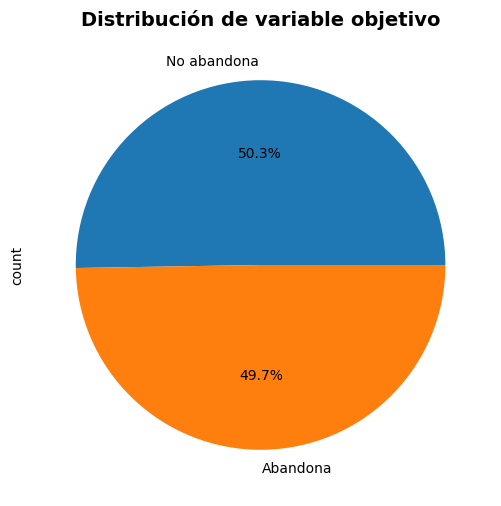

In [5]:
# Revisa la distribución de la variable objetivo
# En este caso se obtiene un gráfico de torta
data[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['No abandona', 'Abandona'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()


## Detección de inconsistencias

In [6]:
data.dtypes

,0
antiguedad_cliente,int64
ingreso_mensual,int64
uso_app_minutos,float64
num_reclamos,int64
dias_desde_ultimo_login,float64
interacciones_soporte,float64
consumo_datos,float64
variacion_consumo,float64
pagos_atrasados,float64
score_satisfaccion,float64


In [7]:
# Detectar inconsistencias
inconsistentes = data[(data["antiguedad_cliente"] < 0) |
 (data["ingreso_mensual"] <= 0) | (data["uso_app_minutos"] < 0) |
  (data["num_reclamos"] < 0) | (data["dias_desde_ultimo_login"] < 0) |
(data["interacciones_soporte"] < 0) | (data["consumo_datos"] < 0) |
(data["pagos_atrasados"] < 0) | (data["score_satisfaccion"] < 0)
  ]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,antiguedad_cliente,ingreso_mensual,uso_app_minutos,num_reclamos,dias_desde_ultimo_login,interacciones_soporte,consumo_datos,variacion_consumo,pagos_atrasados,score_satisfaccion,plan,region,canal_adquisicion,color_app_preferido,churn
1,5,1173416,46.334513,-1,12.541970,19.554713,71.628916,43.180315,11.182667,9.490107,basic,sur,tv,verde,1
2,24,840852,26.117311,-5,3.564252,3.898365,42.272761,42.241841,2.843171,5.895103,premium,sur,email,negro,0
5,25,1019725,37.728806,-6,7.121071,1.847409,58.851414,52.747104,0.981530,11.632023,basic,norte,email,azul,0
6,45,1028761,111.217707,-10,25.871536,37.226613,139.374042,346.570592,2.193507,5.777623,premium,sur,email,verde,0
8,33,172106,68.245740,-16,30.301591,7.225171,54.564300,158.766779,4.222851,30.374895,basic,norte,tv,azul,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,14,-341674,188.801643,2,55.365158,32.076685,141.100148,208.073322,13.355510,2.287156,vip,norte,email,verde,0
19992,16,1371927,130.137446,-7,33.369482,14.795058,52.970532,61.023168,10.679087,10.307856,premium,norte,referido,azul,0
19993,41,1272617,39.944471,-4,16.977801,19.291741,129.632035,233.580628,19.573417,6.954355,premium,centro,referido,verde,1
19998,49,1748243,112.661749,-10,38.914172,23.051382,127.407233,479.774519,23.335922,8.866298,premium,sur,email,verde,1


In [8]:
for columna in ["plan", "region", "color_app_preferido", "canal_adquisicion"]:
  print("Valores: ", data[columna].unique())

Valores:  ['premium' 'basic' 'vip']
Valores:  ['sur' 'centro' 'norte']
Valores:  ['negro' 'verde' 'azul']
Valores:  ['email' 'tv' 'referido' 'instagram']


## Detección de nulos

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   antiguedad_cliente       20000 non-null  int64  
 1   ingreso_mensual          20000 non-null  int64  
 2   uso_app_minutos          20000 non-null  float64
 3   num_reclamos             20000 non-null  int64  
 4   dias_desde_ultimo_login  20000 non-null  float64
 5   interacciones_soporte    20000 non-null  float64
 6   consumo_datos            20000 non-null  float64
 7   variacion_consumo        20000 non-null  float64
 8   pagos_atrasados          20000 non-null  float64
 9   score_satisfaccion       20000 non-null  float64
 10  plan                     20000 non-null  object 
 11  region                   20000 non-null  object 
 12  canal_adquisicion        20000 non-null  object 
 13  color_app_preferido      20000 non-null  object 
 14  churn                 

## Detección de valores atípicos

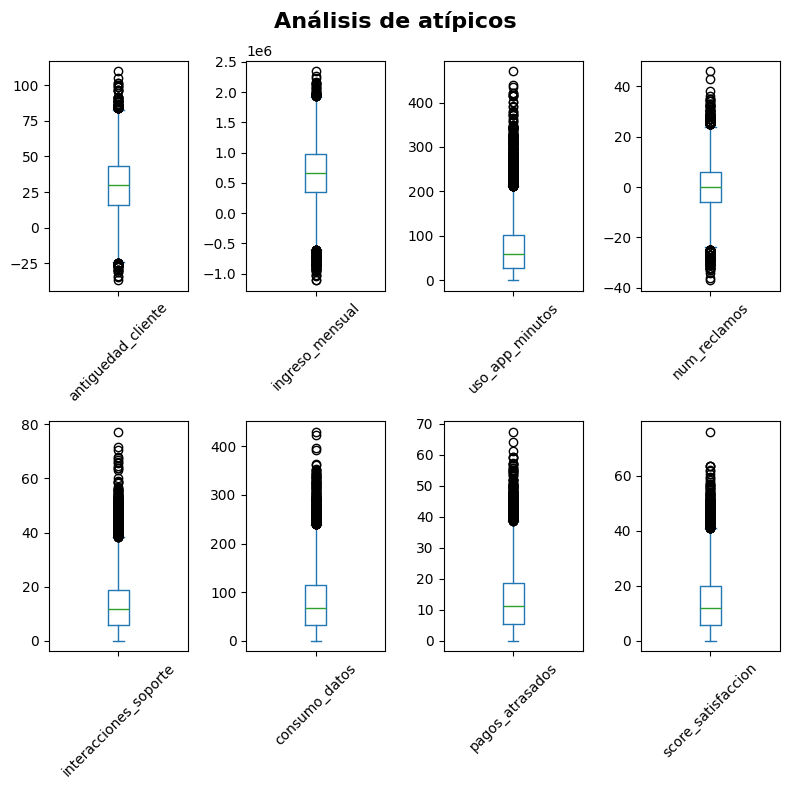

In [10]:
revision_atipicos = ["antiguedad_cliente", "ingreso_mensual", "uso_app_minutos", "num_reclamos",
 "interacciones_soporte", "consumo_datos", "pagos_atrasados",
 "score_satisfaccion"]
# Muestra los gráficos agrupados en 2 filas y 4 columnas
fig, axes = plt.subplots(2, int(len(revision_atipicos) / 2), figsize=(30,30))
#axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  if i < len(revision_atipicos) / 2:
    data[col].plot(kind='box',figsize=(8,8), ax=axes[0, i])
    axes[0, i].tick_params(axis="x", labelrotation=45)
  else:
    data[col].plot(kind='box',figsize=(8,8), ax=axes[1, i-4])
    axes[1, i-4].tick_params(axis="x", labelrotation=45)
plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

## Detección de duplicados

In [11]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(0)

In [12]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)]

,antiguedad_cliente,ingreso_mensual,uso_app_minutos,num_reclamos,dias_desde_ultimo_login,interacciones_soporte,consumo_datos,variacion_consumo,pagos_atrasados,score_satisfaccion,plan,region,canal_adquisicion,color_app_preferido,churn


# Fase 3 - Preparación de datos

### Corrección de inconsistencias: Valores negativos

Basándonos en la detección de inconsistencias, se identificarán las columnas que pueden contener valores negativos y se aplicará la función de valor absoluto para corregirlos.

In [13]:
# Columnas identificadas con posibles valores negativos o cero que deberían ser positivos
columns_to_correct = [
    "antiguedad_cliente", "ingreso_mensual", "uso_app_minutos",
    "num_reclamos", "dias_desde_ultimo_login", "interacciones_soporte",
    "consumo_datos", "pagos_atrasados", "score_satisfaccion"
]

for col in columns_to_correct:
    data[col] = data[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas relevantes.")

Valores negativos corregidos a valores absolutos en las columnas relevantes.


### Re-verificación de inconsistencias

Ahora, se vuelve a ejecutar la detección de inconsistencias para asegurarde que los valores negativos han sido corregidos.

In [14]:
# Detectar inconsistencias nuevamente después de la corrección
inconsistentes_corregido = data[(data["antiguedad_cliente"] < 0) |
 (data["ingreso_mensual"] < 0) | (data["uso_app_minutos"] < 0) |
  (data["num_reclamos"] < 0) | (data["dias_desde_ultimo_login"] < 0) |
(data["interacciones_soporte"] < 0) | (data["consumo_datos"] < 0) |
(data["pagos_atrasados"] < 0) | (data["score_satisfaccion"] < 0)
  ]
print("Registros inconsistentes encontrados después de la corrección:")
display(inconsistentes_corregido)

if inconsistentes_corregido.empty:
    print("¡No se encontraron inconsistencias de valores negativos después de la corrección!")
else:
    print("Aún existen inconsistencias, revisar la lógica.")

Registros inconsistentes encontrados después de la corrección:


,antiguedad_cliente,ingreso_mensual,uso_app_minutos,num_reclamos,dias_desde_ultimo_login,interacciones_soporte,consumo_datos,variacion_consumo,pagos_atrasados,score_satisfaccion,plan,region,canal_adquisicion,color_app_preferido,churn


¡No se encontraron inconsistencias de valores negativos después de la corrección!


**✅ Automatización de fases 3 y 4**

Las fases de preparación y modelamiento se van a automatizar a través del uso de un `pipeline`.

Ventajas de usar esta técnica:

+ Se puede encadenar imputación de nulos, codificación de variables categóricas y el modelo.

+ Permite hacer el mismo preprocesamiento en train y test sin errores.

+ Se vuelve reutilizable para producción o para predecir sobre nuevos datos.

Posible desventaja:

+ Todo queda encapsulado y no se ve fácilmente cómo quedaron los datos después de cada transformación.

In [15]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [16]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None
    self.feature_names_in_ = None

  def fit(self, X, y=None):
    # Ensure X is a DataFrame, assuming upstream transformers use set_output(transform='pandas')
    if not isinstance(X, pd.DataFrame):
        X_df = pd.DataFrame(X)
    else:
        X_df = X.copy()

    self.feature_names_in_ = X_df.columns

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    # Ensure X is a DataFrame
    if not isinstance(X, pd.DataFrame):
        X_df = pd.DataFrame(X)
    else:
        X_df = X.copy()

    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered # Return DataFrame, not .values

  def get_feature_names_out(self, input_features=None):
    current_features = input_features if input_features is not None else self.feature_names_in_

    if current_features is None:
        raise ValueError("CorrelationFilter no tiene acceso a las variables con las que fue entrenado el modelo")

    current_feature_index = pd.Index(current_features)
    output_features = current_feature_index.drop(self.columns_to_drop_, errors='ignore')
    return np.array(output_features)

## Evaluación de las mejores variables `predictoras`

In [17]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

,churn
churn,1.000000
ingreso_mensual,0.266289
interacciones_soporte,0.018002
dias_desde_ultimo_login,-0.006634
consumo_datos,-0.009630
num_reclamos,-0.014216
score_satisfaccion,-0.016667
uso_app_minutos,-0.070228
pagos_atrasados,-0.071186
variacion_consumo,-0.155088


In [18]:
for columna in ["plan", "region", "color_app_preferido", "canal_adquisicion"]:
  print(f"Análisis {columna}")
  display(data.groupby(columna)[target].value_counts().sort_values().round(2))

Análisis plan


,,count
plan,churn,
vip,0,3272
basic,0,3306
premium,1,3318
basic,1,3324
premium,0,3370
vip,1,3410


Análisis region


region  churn
norte   1        3238
        0        3287
sur     0        3323
centro  0        3338
        1        3364
sur     1        3450
Name: count, dtype: int64

Análisis color_app_preferido


color_app_preferido  churn
verde                0        3257
negro                1        3314
                     0        3337
azul                 0        3354
                     1        3361
verde                1        3377
Name: count, dtype: int64

Análisis canal_adquisicion


,,count
canal_adquisicion,churn,
instagram,0,2410
tv,0,2459
email,0,2464
instagram,1,2484
tv,1,2510
referido,1,2517
email,1,2541
referido,0,2615


# Fase 4 - Modelamiento

In [19]:
data.describe().columns

Index(['antiguedad_cliente', 'ingreso_mensual', 'uso_app_minutos',
       'num_reclamos', 'dias_desde_ultimo_login', 'interacciones_soporte',
       'consumo_datos', 'variacion_consumo', 'pagos_atrasados',
       'score_satisfaccion', 'churn'],
      dtype='object')

In [20]:
# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

In [21]:
# Variables
features_num = ['antiguedad_cliente', 'ingreso_mensual', 'uso_app_minutos',
       'num_reclamos', 'dias_desde_ultimo_login', 'interacciones_soporte',
       'consumo_datos', 'variacion_consumo', 'pagos_atrasados',
       'score_satisfaccion']
features_cat = ["plan", "region", "color_app_preferido", "canal_adquisicion"]

X = data[features_num + features_cat]
y = data[target]

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough"
)
preprocessor.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('winsorizer', Winsorizer()),
                                                 ('imputer', SimpleImputer()),
                                                 ('escalado',
                                                  StandardScaler())]),
                                 ['antiguedad_cliente', 'ingreso_mensual',
                                  'uso_app_minutos', 'num_reclamos',
                                  'dias_desde_ultimo_login',
                                  'interacciones_soporte', 'consumo_datos',
                                  'variacion_consumo', 'pagos_atrasados',
                                  'score_satisfaccion']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['plan', 'region', 'color_app_preferido',
                                  'canal_adquisicion'])])

In [23]:
def evaluar(modelo: BaseEstimator, X_train: np.array, X_test: np.array, y_train: np.array, y_test: np.array):
  """
  Retorna las métricas del modelo

  Parámetros
  ----------
  modelo : BaseEstimator
    Modelo a evaluar.
  X_train : np.array
    Conjunto de datos de entrenamiento.
  X_test : np.array
    Conjunto de datos de prueba.
  y_train : np.array
    Etiquetas de entrenamiento.
  y_test : np.array
    Etiquetas de prueba
  Returns
  -------
  dict
    Diccionario con las métricas del modelo.

  """
  modelo.fit(X_train, y_train)

  y_pred = modelo.predict(X_test)
  y_prob = modelo.predict_proba(X_test)[:,1]

  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

In [24]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)

# LogisticRegression

## Modelo base

In [25]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_lr = Pipeline(steps=[
    ("preprocesador", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LogisticRegression())
])

In [26]:
# Evaluación
metricas_lr = evaluar(pipeline_modelo_lr, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_lr['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_lr['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_lr['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_lr['recall']:.4f}")

Accuracy            : 0.6548
F1 Score:           : 0.6476
ROC AUC Score       : 0.7078
Precision           : 0.6647
Recall              : 0.6313


In [27]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.66263
Score del modelo en test                :0.65475


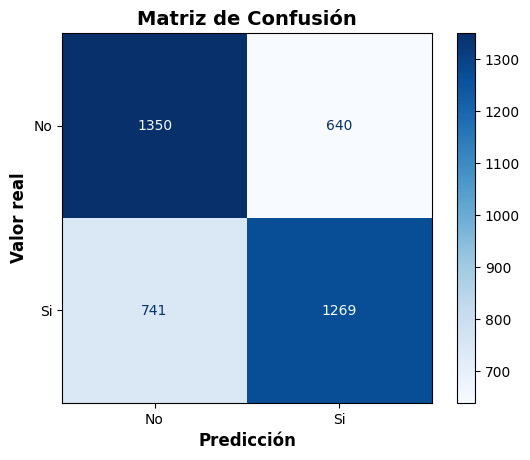

In [28]:
y_pred = pipeline_modelo_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Si"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

## Aplicando GridSearchCV

In [29]:
param_grid_lr = {
      'modelo__penalty': ['l2'],
      'modelo__C': [0.01, 0.1, 1, 10, 100],
      'modelo__max_iter': [500, 1000]}

In [30]:
grid_lr = GridSearchCV(
    pipeline_modelo_lr,
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('escalado',
                                                                                          StandardScaler())]),
                                                                         ['antiguedad_cliente',
                                                                          'ingreso_mensual',
                                                                          'uso_app_minutos',
                                                                          'num_recl...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['plan',
                                                                          'region',
                                                                          'color_app_preferido',
                                                                          'canal_adquisicion'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'modelo__C': [0.01, 0.1, 1, 10, 100],
                         'modelo__max_iter': [500, 1000],
                         'modelo__penalty': ['l2']},
             scoring='f1')

In [31]:
grid_lr.best_params_

{'modelo__C': 0.01, 'modelo__max_iter': 500, 'modelo__penalty': 'l2'}

In [32]:
best_model_lr = grid_lr.best_estimator_
# Evaluación
metricas_lr_mejor = evaluar(best_model_lr, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_lr_mejor['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_lr_mejor['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr_mejor['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_lr_mejor['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_lr_mejor['recall']:.4f}")

Accuracy            : 0.6538
F1 Score:           : 0.6461
ROC AUC Score       : 0.7079
Precision           : 0.6642
Recall              : 0.6289


In [33]:
print(f"{'Score del modelo en entrenamiento':<40}:{best_model_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{best_model_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.66356
Score del modelo en test                :0.65375


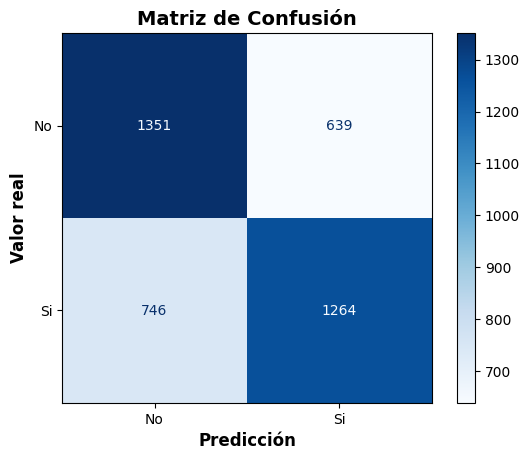

In [34]:
y_pred = best_model_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Si"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

# DecisionTreeClassifier

## Modelo linea base

```python
DecisionTreeClassifier(max_depth=None)

In [35]:
# Preprocesamiento numérico: imputación con media
numeric_transformer_dt = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean"))
])

preprocessor_dt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_dt, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough"
)

In [36]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_dtc = Pipeline(steps=[
    ("preprocesador", preprocessor_dt),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeClassifier())
])

In [37]:
# Evaluación
metricas_dtc = evaluar(pipeline_modelo_dtc, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc['recall']:.4f}")

Accuracy            : 0.8120
F1 Score:           : 0.8140
ROC AUC Score       : 0.8120
Precision           : 0.8095
Recall              : 0.8184


In [38]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_dtc.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_dtc.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :1.00000
Score del modelo en test                :0.81200


In [39]:
X.columns

Index(['antiguedad_cliente', 'ingreso_mensual', 'uso_app_minutos',
       'num_reclamos', 'dias_desde_ultimo_login', 'interacciones_soporte',
       'consumo_datos', 'variacion_consumo', 'pagos_atrasados',
       'score_satisfaccion', 'plan', 'region', 'color_app_preferido',
       'canal_adquisicion'],
      dtype='object')

## Modelo 2

In [40]:
param_grid_dt = {
    "modelo__max_depth": range(3,6),
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
    "modelo__class_weight": [None, "balanced"]
}

grid_dt = GridSearchCV(
    pipeline_modelo_dtc,
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['antiguedad_cliente',
                                                                          'ingreso_mensual',
                                                                          'uso_app_minutos',
                                                                          'num_reclamos',
                                                                          'dias_desde_ultimo_login...
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['plan',
                                                                          'region',
                                                                          'color_app_preferido',
                                                                          'canal_adquisicion'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': [None, 'balanced'],
                         'modelo__max_depth': range(3, 6),
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [41]:
mejor_modelo_dtc = grid_dt.best_estimator_

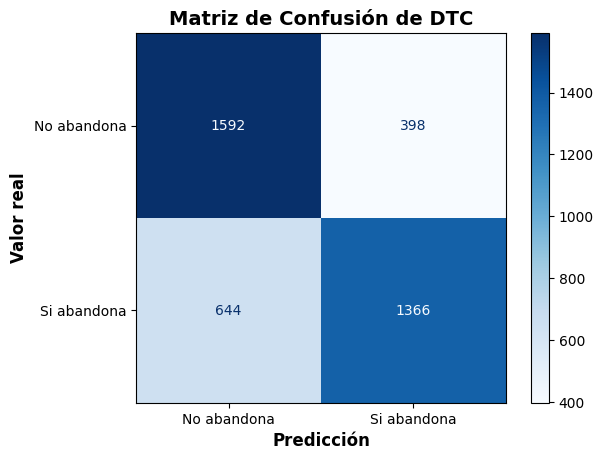

In [42]:
y_pred = mejor_modelo_dtc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandona", "Si abandona"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión de DTC", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

In [43]:
# Evaluación
metricas_dtc = evaluar(mejor_modelo_dtc, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc['recall']:.4f}")

Accuracy            : 0.7395
F1 Score:           : 0.7239
ROC AUC Score       : 0.8114
Precision           : 0.7744
Recall              : 0.6796


In [44]:
# Obtiene las probabilidades
y_pred_proba = mejor_modelo_dtc.predict_proba(X_test)[:, 1]

In [45]:
def verMatrizUmbral(a_probabilidades: np.array, umbral: float):
  """
  Obtiene la matriz de confusión usando un determinado umbral

  Parámetros
  ----------
  a_probabilidades : np.array
    Probabilidades de la clase positiva.
  umbral : float
    Umbral para la clasificación.
  """
  y_pred_umbral = (a_probabilidades >= umbral).astype(int)
  cm = confusion_matrix(y_test_sin_sospecha, y_pred_umbral)
  y_pred_umbral = (y_pred_proba >= umbral).astype(int)
  cm = confusion_matrix(y_test_sin_sospecha, y_pred_umbral)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandona", "Si abandona"])
  disp.plot(cmap="Blues")
  plt.title(f"Matriz de Confusión con umbral {umbral}", fontweight="bold", fontsize=14)
  plt.xlabel("Predicción", fontweight="bold", fontsize=12)
  plt.ylabel("Valor real", fontweight="bold", fontsize=12)
  plt.show()

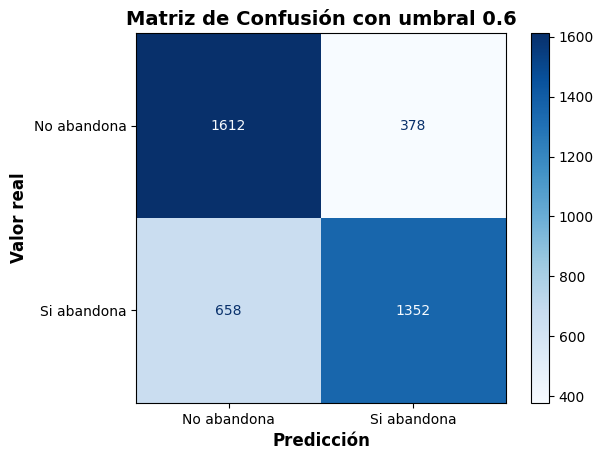

In [46]:
# Obtiene las predicciones
umbral = 0.6
y_pred_umbral = (y_pred_proba >= umbral).astype(int)
cm = confusion_matrix(y_test, y_pred_umbral)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandona", "Si abandona"])
disp.plot(cmap="Blues")
plt.title(f"Matriz de Confusión con umbral {umbral}", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

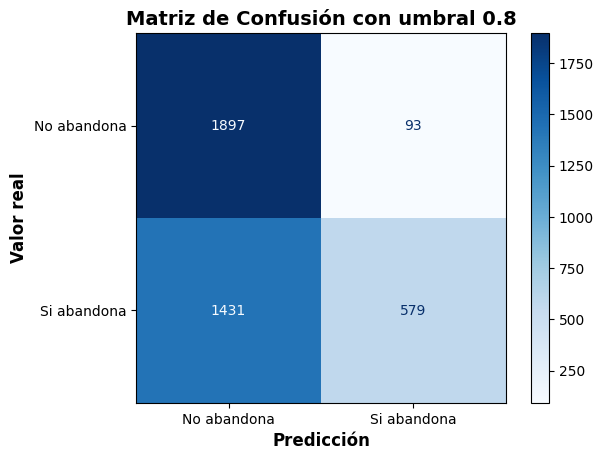

In [47]:
# Obtiene las predicciones
umbral = 0.8
y_pred_umbral = (y_pred_proba >= umbral).astype(int)
cm = confusion_matrix(y_test, y_pred_umbral)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandona", "Si abandona"])
disp.plot(cmap="Blues")
plt.title(f"Matriz de Confusión con umbral {umbral}", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

In [48]:
print(f"{'Score del modelo en entrenamiento':<40}:{mejor_modelo_dtc.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{mejor_modelo_dtc.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.75994
Score del modelo en test                :0.73950


In [49]:
grid_dt.best_params_

{'modelo__class_weight': None,
 'modelo__max_depth': 5,
 'modelo__min_samples_leaf': 1,
 'modelo__min_samples_split': 2}

In [50]:
mejor_modelo = mejor_modelo_dtc.named_steps["modelo"]

Profundidad del árbol: 5
Número de nodos terminales: 32


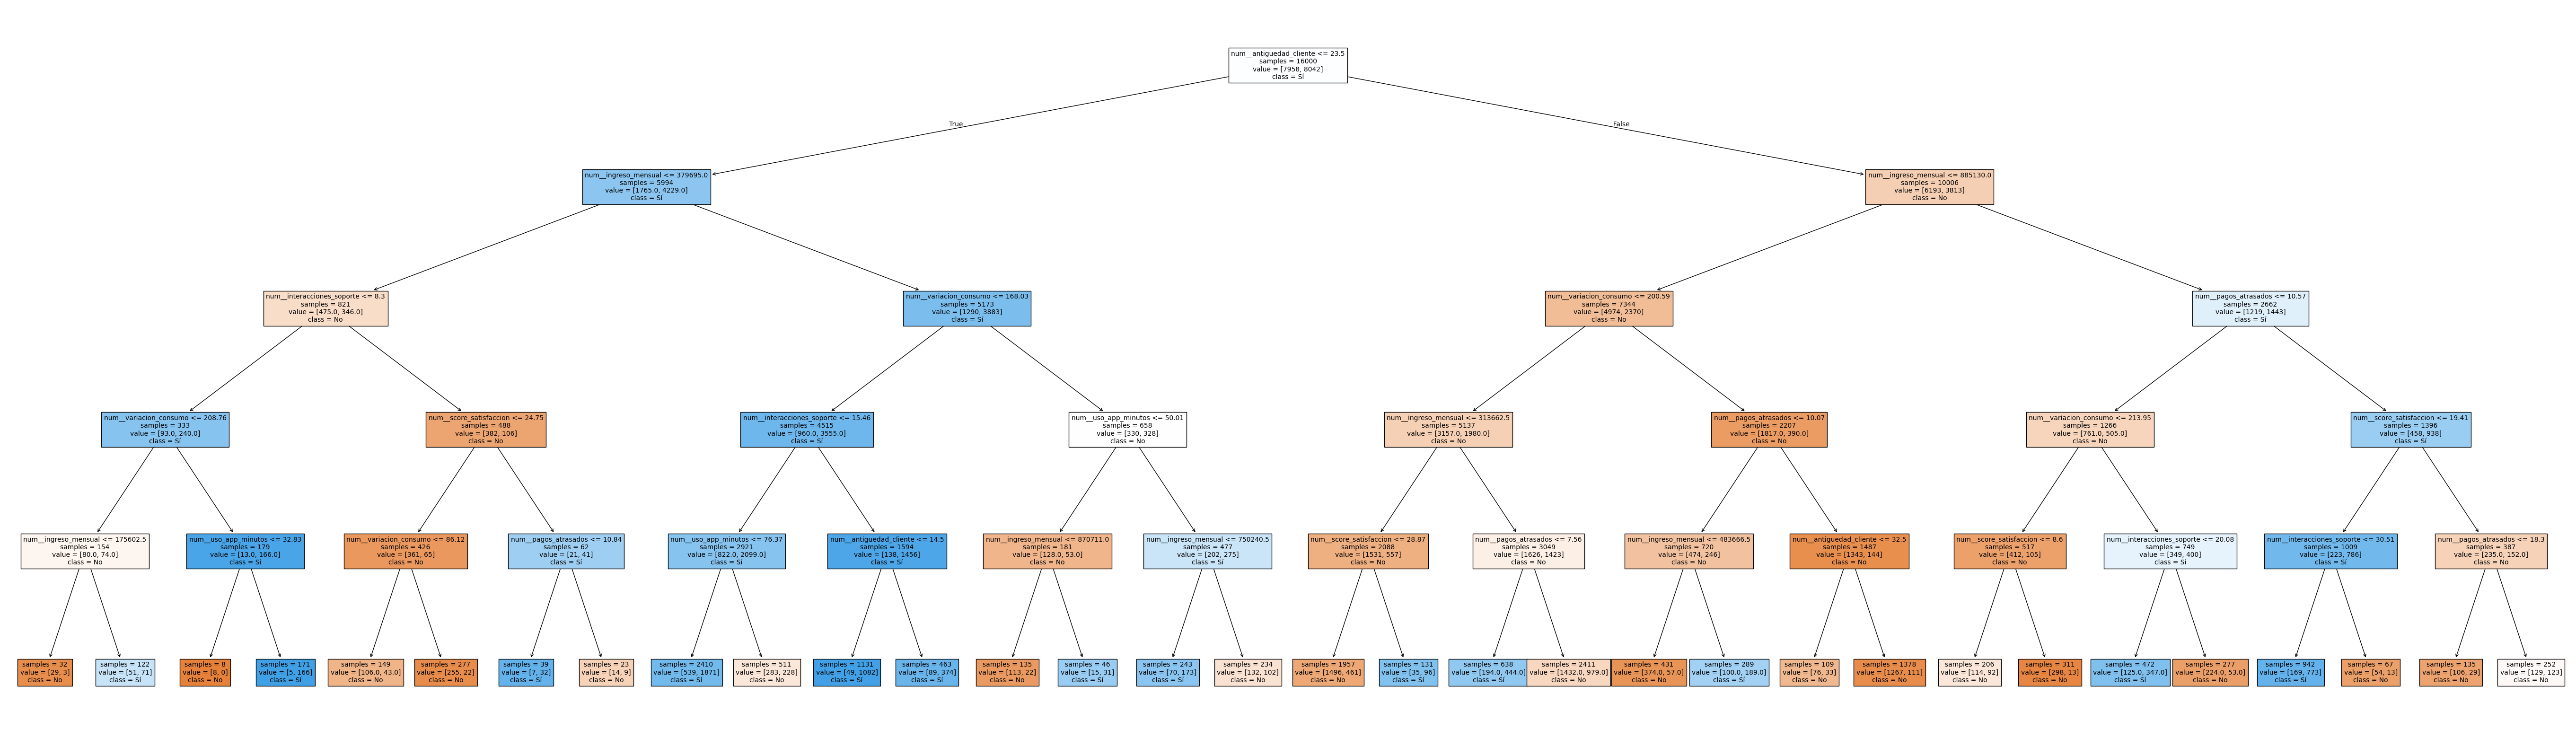

In [51]:
fig, ax = plt.subplots(figsize=(70, 20))

print(f"Profundidad del árbol: {mejor_modelo.get_depth()}")
print(f"Número de nodos terminales: {mejor_modelo.get_n_leaves()}")

plot = plot_tree(
            decision_tree = mejor_modelo,
            feature_names = mejor_modelo_dtc[:-1].get_feature_names_out(),
            class_names = ["No", "Sí"],
            filled         = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

## Modelo seleccionando las mejores variables predictoras

In [52]:
correlacion_objetivo

,churn
churn,1.000000
ingreso_mensual,0.266289
interacciones_soporte,0.018002
dias_desde_ultimo_login,-0.006634
consumo_datos,-0.009630
num_reclamos,-0.014216
score_satisfaccion,-0.016667
uso_app_minutos,-0.070228
pagos_atrasados,-0.071186
variacion_consumo,-0.155088


In [53]:
def mejores_predictoras(correlacion_objetivo: np.array, target, umbral = 0.5):
  """
  Obtiene las mejores variables predictoras en función de un umbral de correlación

  Parámetros
  ----------
  correlacion_objetivo : np.array
    Matriz de correlación con la variable objetivo.
  umbral : float
    Umbral de correlación para seleccionar las variables predictoras.
  Returns
  -------
  np.array
    Nombres de las variables predictoras seleccionadas.
  """
  return correlacion_objetivo[(abs(correlacion_objetivo) > umbral) &
                              (correlacion_objetivo.index != target)].sort_values(ascending=False).index.values

In [54]:
# Elige las mejores variables predictoras en función de un umbral de correlación
umbral_correlacion = 0.15
mejores = mejores_predictoras(correlacion_objetivo, target, umbral = umbral_correlacion)
mejores

array(['ingreso_mensual', 'variacion_consumo', 'antiguedad_cliente'],
      dtype=object)

In [55]:
# Variables
features_num = list(mejores)
features_cat = ["plan", "region", "color_app_preferido", "canal_adquisicion"]

X = data[features_num + features_cat]
y = data[target]

In [56]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)

In [57]:
X_train.columns

Index(['ingreso_mensual', 'variacion_consumo', 'antiguedad_cliente', 'plan',
       'region', 'color_app_preferido', 'canal_adquisicion'],
      dtype='object')

In [58]:
# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer_dt = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean"))
])

preprocessor_dt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_dt, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough"
)

# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_dtc = Pipeline(steps=[
    ("preprocesador", preprocessor_dt),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeClassifier())
])

grid_dt = GridSearchCV(
    pipeline_modelo_dtc,
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['ingreso_mensual',
                                                                          'variacion_consumo',
                                                                          'antiguedad_cliente']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          S...
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['plan',
                                                                          'region',
                                                                          'color_app_preferido',
                                                                          'canal_adquisicion'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': [None, 'balanced'],
                         'modelo__max_depth': range(3, 6),
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [59]:
mejor_modelo_x = grid_dt.best_estimator_

In [60]:
# Evaluación
metricas_dtc_x = evaluar(mejor_modelo_x, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc_x['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc_x['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc_x['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc_x['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc_x['recall']:.4f}")

Accuracy            : 0.6900
F1 Score:           : 0.6824
ROC AUC Score       : 0.7647
Precision           : 0.7033
Recall              : 0.6627


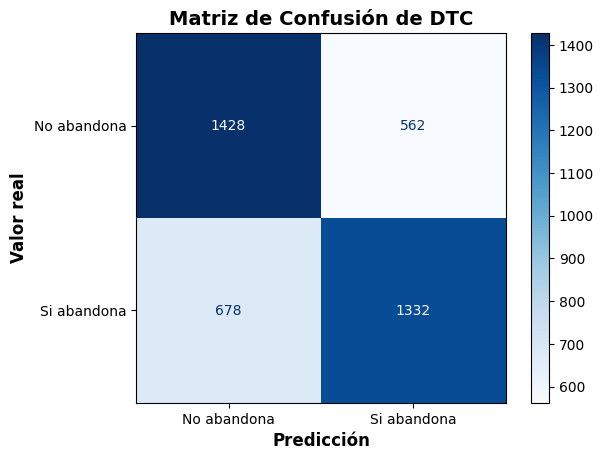

In [61]:
y_pred = mejor_modelo_x.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandona", "Si abandona"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión de DTC", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

Profundidad del árbol: 5
Número de nodos terminales: 32


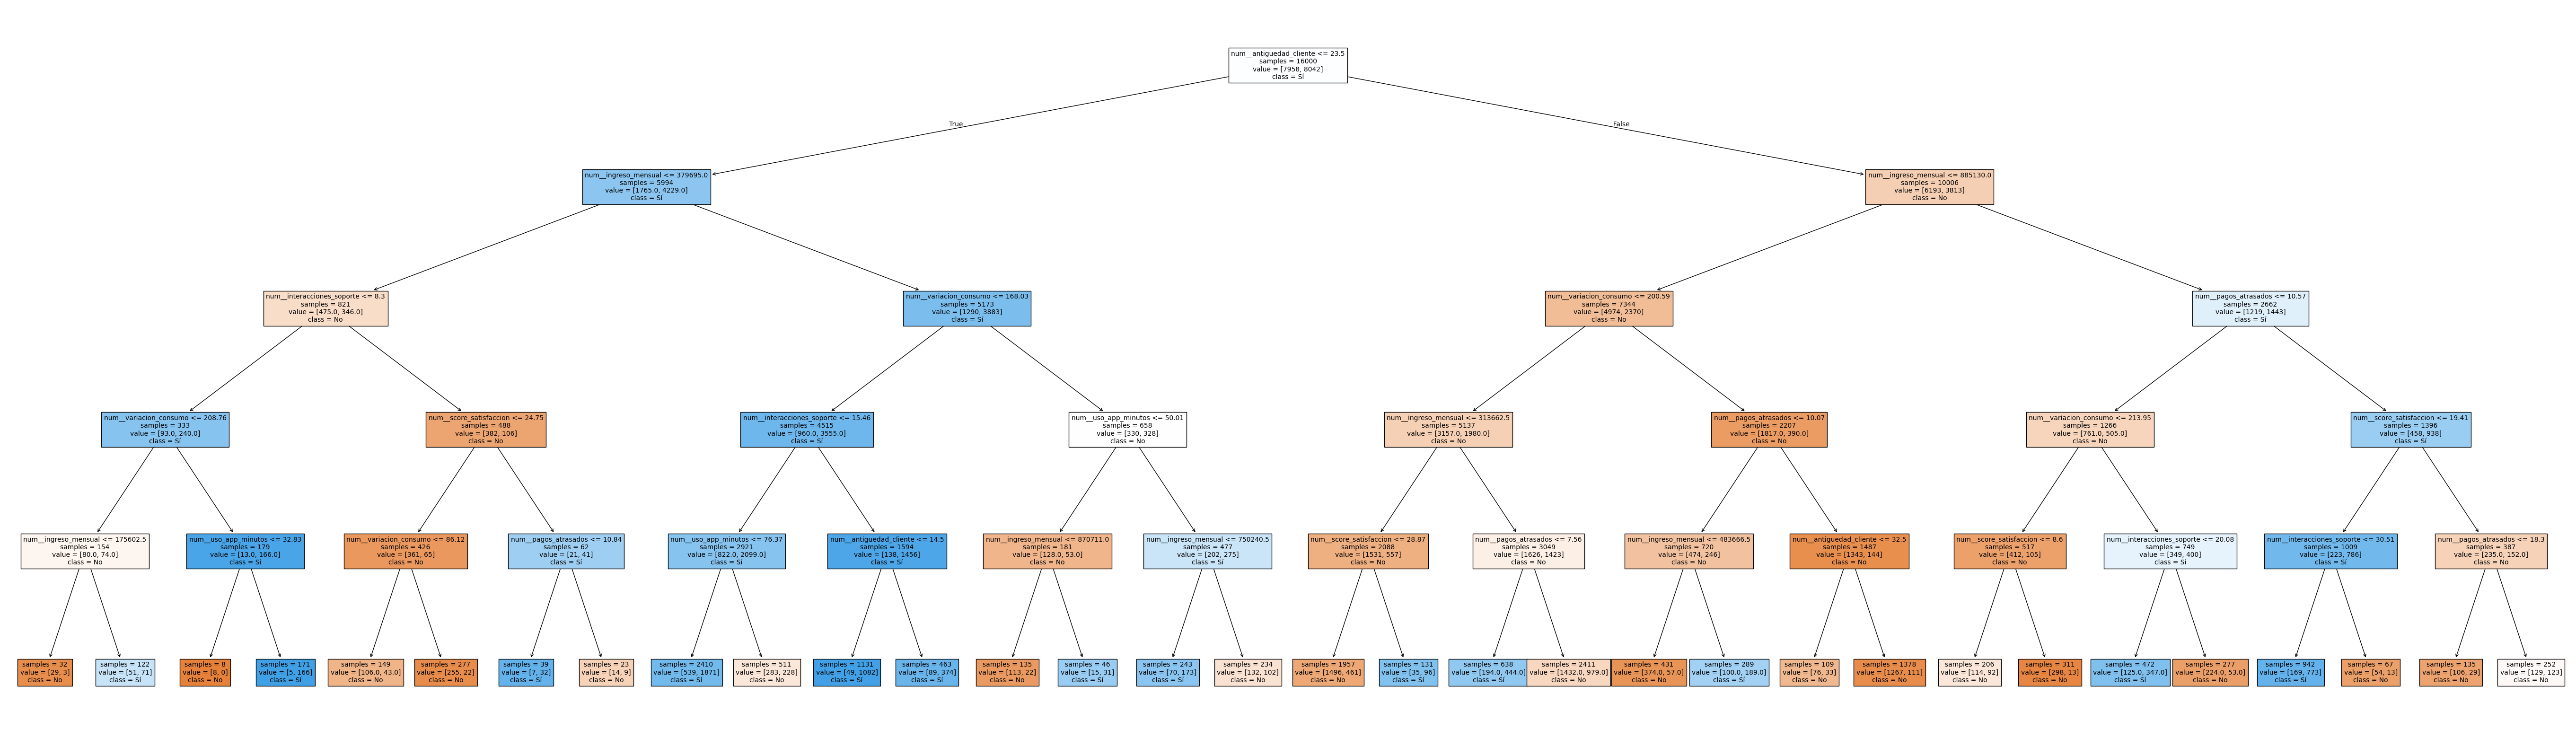

In [62]:
fig, ax = plt.subplots(figsize=(70, 20))

print(f"Profundidad del árbol: {mejor_modelo_x.named_steps["modelo"].get_depth()}")
print(f"Número de nodos terminales: {mejor_modelo_x.named_steps["modelo"].get_n_leaves()}")

plot = plot_tree(
            decision_tree = mejor_modelo,
            feature_names = mejor_modelo_dtc[:-1].get_feature_names_out(),
            class_names = ["No", "Sí"],
            filled         = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

In [63]:
print(f"{'Score del modelo en entrenamiento':<40}:{mejor_modelo_x.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{mejor_modelo_x.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.69912
Score del modelo en test                :0.69000
